# EV Session-Energy Model — residential charging, Dingle (Ireland)

**EnerTEF · TEF-EV · Service 4 — EV-User Charging and Usage Profiles Prediction · D2.2 §2.5.4**

Predicts the **energy a home charging session will deliver** (kWh) at the q10 / q50 / q90 quantiles,
from context available just before the session starts: recent driving, time since the last charge,
the tariff band and the PV already generated that day. Downstream smart-charging gets a point
estimate *and* an uncertainty band.

This notebook is the complete, self-contained model pipeline: it loads the dataset, reconstructs the
pre-session context of every real session, selects the learning algorithm with a rule fixed before
the experiment, trains and evaluates the final model, and writes it — with its Hugging Face model
card — to `Data/models/`. The exploratory analysis behind the service (charging behaviour, timing
and volume heads, counterfactuals) is in `EV_Charging_Analysis.ipynb`.

## Data access

The **Residential Energy Dataset with Electric Vehicles, PV Generation and Tariff Variability in
Ireland** (Scientific Data 13:834, 2026) describes four real households and is **not redistributed
in this repository**. Obtain it from its owners via the data paper, then place (or point to) it:

```
Data/
  JourneyCharge/idNN_Sorted_Mobility.csv   # journeys + charging events
  EnergyStreams/idNN_merged_30min*.csv     # 30-min solar_kWh + elec_price
```

or set `DINGLE_DATASET_ROOT` to the folder that contains `JourneyCharge/` and `EnergyStreams/`.

## How to run

```bash
py -3.11 -m venv .venv            # Python 3.11 (3.12 also works; 3.13 is not supported, see requirements.txt)
.venv\Scripts\activate            # macOS / Linux: python3.11 -m venv .venv && source .venv/bin/activate
pip install -r requirements.txt
jupyter lab EV_Session_Energy_Model.ipynb
```

Run it top to bottom from the repository root (well under a minute).

The exported `.joblib` is a pickle and only loads on the scikit-learn release that wrote it (**1.5.2**, pinned in
`requirements.txt`). Setup therefore refuses to run on another release, and §7 refuses to export, so a model that the
published environment cannot load is never written.

| § | Section | Produces |
|---|---|---|
| 1 | Setup | paths, constants, library versions (scikit-learn must be 1.5.2) |
| 2 | Data | charging sessions, journeys and energy streams per household |
| 3 | Features | the 7-feature pre-session context of every session, leakage-safe |
| 4 | Split and baselines | chronological 80/20 split, the physics-lite baseline and two no-model references |
| 5 | Algorithm bake-off | GBR vs LightGBM vs XGBoost over 3 seeds and the pre-registered rule's verdict |
| 6 | Final model and evaluation | hold-out accuracy vs the baseline and the no-model references, per household |
| 7 | Export | `Data/models/`: `.joblib` model, metrics, bake-off, pinned `requirements.txt`, model card |
| 8 | Publish to Hugging Face | opt-in, permission-checked upload of `Data/models/` to the EnerTEF organisation |

## 1 · Setup

In [1]:
import json
import os
import platform
import statistics
import time
from datetime import datetime, timedelta, timezone
from importlib.metadata import version
from pathlib import Path

# joblib cannot count physical cores on recent Windows (no `wmic`) and prints a traceback when
# LightGBM asks for them; a core count below the logical total makes it skip that probe.
if os.name == "nt":
    os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(max(1, (os.cpu_count() or 2) // 2)))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from lightgbm import LGBMRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

ROOT = Path.cwd()
DATA_DIR = Path(os.environ.get("DINGLE_DATASET_ROOT") or ROOT / "Data")
MODEL_DIR = ROOT / "Data" / "models"
if not (DATA_DIR / "JourneyCharge").is_dir() or not (DATA_DIR / "EnergyStreams").is_dir():
    raise FileNotFoundError(
        f"Dataset not found under {DATA_DIR}: expected JourneyCharge/ and EnergyStreams/. "
        "Place the restricted dataset in Data/ or set DINGLE_DATASET_ROOT (see 'Data access' above)."
    )
MODEL_DIR.mkdir(parents=True, exist_ok=True)

HOUSEHOLDS = ["id01", "id02", "id03", "id04"]
QUANTILES = {"q10": 0.1, "q50": 0.5, "q90": 0.9}
TEST_FRACTION = 0.2                       # most recent fifth of the sessions is held out
MODEL_VERSION = "1.0.0"
HF_REPO = "EnerTEF/EV-Service4-User-Charging-and-Usage-Profiles-Prediction"
GITHUB_REPO = "https://github.com/ENERTEF/TEF-EV-Service-4----EV-User-Charging-and-Usage-Profiles-Prediction-Service"

LIBS = {lib: version(lib) for lib in ("numpy", "pandas", "scikit-learn", "lightgbm", "xgboost", "joblib")}
print(f"dataset: {DATA_DIR.relative_to(ROOT).as_posix() if DATA_DIR.is_relative_to(ROOT) else '$DINGLE_DATASET_ROOT'}")
print(f"python {platform.python_version()} · " + " · ".join(f"{lib} {v}" for lib, v in LIBS.items()))

# The exported .joblib is a pickle: it only loads on the scikit-learn release that wrote it. The published model was
# written with 1.5.2 and does NOT load on >= 1.6 (AttributeError: '__pyx_unpickle_CyPinballLoss').
REFERENCE_SKLEARN = "1.5.2"
if LIBS["scikit-learn"] != REFERENCE_SKLEARN and not os.environ.get("ALLOW_OTHER_SKLEARN"):
    raise RuntimeError(
        f"scikit-learn {LIBS['scikit-learn']} found, {REFERENCE_SKLEARN} required: a model exported here would not load in the "
        "published environment. Use Python 3.11 and `pip install -r requirements.txt` "
        "(set ALLOW_OTHER_SKLEARN=1 only to explore: the export in section 7 is still refused).")

dataset: Data
python 3.11.9 · numpy 1.26.4 · pandas 2.2.3 · scikit-learn 1.5.2 · lightgbm 4.5.0 · xgboost 2.1.3 · joblib 1.4.2


## 2 · Data — sessions, journeys and energy streams

Per household, `JourneyCharge/` holds the event log (journeys with distance, charging sessions with
delivered energy) and `EnergyStreams/` the 30-minute solar generation and electricity price. Event
timestamps are naive and read as UTC; charging events without positive energy and journeys without
positive distance are dropped. Each session gets a **tariff band** from the price in its start slot,
classified by the household's own price terciles (off-peak ≤ lower tercile, peak ≥ upper tercile,
shoulder in between).

In [2]:
def find_file(subdir: str, household: str) -> Path | None:
    for pattern in (f"{household}_*.csv", f"{household}*.csv"):
        matches = sorted((DATA_DIR / subdir).glob(pattern))
        if matches:
            return matches[0]
    return None


def parse_event_ts(value) -> datetime | None:
    try:
        return datetime.strptime(str(value).strip(), "%Y-%m-%d %H:%M:%S").replace(tzinfo=timezone.utc)
    except ValueError:
        return None


def parse_float(value) -> float | None:
    text = str(value).strip()
    try:
        return float(text) if text else None
    except ValueError:
        return None


def charging_minutes(value) -> float | None:
    # CHARGING_TIME as HH:MM:SS → minutes (used only when end_time is missing).
    parts = str(value).strip().split(":")
    try:
        h, m, s = (int(p) for p in parts)
    except ValueError:
        return None
    return h * 60 + m + s / 60.0


def load_events(household: str) -> tuple[list[dict], list[dict]]:
    # Charging sessions and journeys of one household.
    log = pd.read_csv(find_file("JourneyCharge", household), dtype=str, keep_default_na=False)
    sessions, journeys = [], []
    for row in log.to_dict("records"):
        event = (row.get("event_type") or "").strip().lower()
        start = parse_event_ts(row.get("start_time", ""))
        if start is None:
            continue
        if event == "charging":
            energy = parse_float(row.get("ENERGY", ""))
            if energy is None or energy <= 0:
                continue
            end = parse_event_ts(row.get("end_time", ""))
            if end is None:
                end = start + timedelta(minutes=charging_minutes(row.get("CHARGING_TIME", "")) or 0.0)
            sessions.append({"start": start, "end": end, "energy_kwh": energy})
        elif event == "journey":
            distance = parse_float(row.get("Distance", ""))
            if distance is not None and distance > 0:
                journeys.append({"start": start, "distance_km": distance})
    return sessions, journeys


def load_stream(household: str) -> dict[datetime, tuple[float | None, float | None]]:
    # 30-min slot → (solar_kWh, elec_price).
    df = pd.read_csv(find_file("EnergyStreams", household), dtype=str, keep_default_na=False)
    stream = {}
    for ts, solar, price in zip(df["timestamp"], df["solar_kWh"], df["elec_price"]):
        try:
            slot = datetime.fromisoformat(ts.strip()).astimezone(timezone.utc)
        except ValueError:
            continue
        stream[slot] = (parse_float(solar), parse_float(price))
    return stream


def slot_of(ts: datetime) -> datetime:
    return ts.replace(minute=0 if ts.minute < 30 else 30, second=0, microsecond=0)


def tariff_band(price: float | None, terciles: tuple[float, float] | None) -> str | None:
    if price is None or terciles is None:
        return None
    low, high = terciles
    return "off_peak" if price <= low else "peak" if price >= high else "shoulder"


data = {}
for hid in HOUSEHOLDS:
    sessions, journeys = load_events(hid)
    stream = load_stream(hid)
    prices = sorted(p for _, p in stream.values() if p is not None)
    terciles = tuple(statistics.quantiles(prices, n=3)) if len(prices) >= 3 and prices[0] != prices[-1] else None
    for s in sessions:
        s["tariff_band"] = tariff_band(stream.get(slot_of(s["start"]), (None, None))[1], terciles)
    data[hid] = {"sessions": sessions, "journeys": journeys, "stream": stream}

display(pd.DataFrame(
    {hid: {"charging sessions": len(d["sessions"]), "journeys": len(d["journeys"]),
           "30-min stream slots": len(d["stream"]),
           "first session": min(s["start"] for s in d["sessions"]).date(),
           "last session": max(s["start"] for s in d["sessions"]).date(),
           "median energy (kWh)": round(float(np.median([s["energy_kwh"] for s in d["sessions"]])), 1)}
     for hid, d in data.items()}
).T)

,charging sessions,journeys,30-min stream slots,first session,last session,median energy (kWh)
id01,153,2314,52945,2021-02-04,2022-01-25,10.9
id02,292,3481,54095,2021-02-01,2022-01-30,24.0
id03,89,6265,52129,2021-02-11,2022-01-27,29.2
id04,200,6223,53569,2021-02-05,2022-01-30,29.1


## 3 · Features — the pre-session context

A prediction is **issued at the moment a session starts**, from what is known up to then. For every
real session the context is rebuilt from the event log and the energy stream, strictly before the
session start:

| Feature | Meaning |
|---|---|
| `recent_trip_km` | distance driven since the previous session ended (last 24 h for the first session) |
| `trips_today` | journeys started earlier the same day |
| `hours_since_last_charge` | hours since the previous session ended (18 h prior for the first session) |
| `tariff_ordinal` | tariff band at the start: off-peak 0, shoulder 1, standard 2 (unknown), peak 3 |
| `pv_today_kwh` | PV generated since midnight |
| `hour_of_day` | fractional hour of the session start (UTC) |
| `is_weekend` | 1 on Saturday / Sunday |

In [3]:
FEATURES = ["recent_trip_km", "trips_today", "hours_since_last_charge", "tariff_ordinal",
            "pv_today_kwh", "hour_of_day", "is_weekend"]
TARIFF_ORDINAL = {"off_peak": 0, "shoulder": 1, "standard": 2, "peak": 3}
DEFAULT_HOURS_SINCE_LAST_CHARGE = 18.0


def pv_today_kwh(stream: dict, until: datetime) -> float:
    cursor, total = until.replace(hour=0, minute=0, second=0, microsecond=0), 0.0
    while cursor < until:
        solar = stream.get(slot_of(cursor), (None, None))[0]
        if solar:
            total += solar
        cursor += timedelta(minutes=30)
    return round(total, 3)


rows = []
for hid in HOUSEHOLDS:
    d = data[hid]
    prev_end = None
    for s in sorted(d["sessions"], key=lambda x: x["start"]):
        start = s["start"]
        window_start = prev_end if prev_end is not None else start - timedelta(hours=24)
        rows.append({
            "household": hid,
            "start": start,
            "recent_trip_km": round(sum(j["distance_km"] for j in d["journeys"] if window_start <= j["start"] < start), 3),
            "trips_today": sum(1 for j in d["journeys"] if j["start"].date() == start.date() and j["start"] < start),
            "hours_since_last_charge": (max(0.0, (start - prev_end).total_seconds() / 3600.0)
                                        if prev_end is not None else DEFAULT_HOURS_SINCE_LAST_CHARGE),
            "tariff_ordinal": float(TARIFF_ORDINAL.get(s["tariff_band"] or "standard", 2)),
            "pv_today_kwh": pv_today_kwh(d["stream"], start),
            "hour_of_day": start.hour + start.minute / 60.0,
            "is_weekend": 1.0 if start.weekday() >= 5 else 0.0,
            "energy_kwh": s["energy_kwh"],
        })
        prev_end = s["end"]
table = pd.DataFrame(rows)
print(f"{len(table)} sessions with reconstructed context")
display(table[FEATURES + ["energy_kwh"]].describe().T.round(2))

734 sessions with reconstructed context


,count,mean,std,min,25%,50%,75%,max
recent_trip_km,734.0,118.94,140.06,0.00,4.20,71.79,186.19,1133.40
trips_today,734.0,8.59,7.72,0.00,0.00,8.00,14.00,37.00
hours_since_last_charge,734.0,38.30,58.63,0.00,6.49,15.68,52.00,607.56
tariff_ordinal,734.0,0.87,0.53,0.00,1.00,1.00,1.00,3.00
pv_today_kwh,734.0,2.54,3.63,0.00,0.00,0.47,4.17,15.83
hour_of_day,734.0,15.70,7.47,0.00,11.66,18.63,21.70,23.97
is_weekend,734.0,0.26,0.44,0.00,0.00,0.00,1.00,1.00
energy_kwh,734.0,26.74,19.60,0.01,8.70,23.97,43.39,71.27


## 4 · Chronological split and the baselines

Sessions are sorted by start time across households; the earlier **80 %** train, the most recent
**20 %** are held out. The **baseline** is the physics-lite rule a service can use without a trained
model: energy = recent distance × 0.18 kWh/km (+5 % per trip beyond the first), clamped to
1–80 kWh, with a ±25 % band.

That rule is a weak yardstick on its own (it can be worse than guessing a constant), so two **no-model references**
are scored on the same hold-out: a **constant** (the training median, with the training q10–q90 as its band) and the
**household's trailing median** of its previous five sessions. Neither uses driving data or a trained model.

In [4]:
order = np.argsort([t.timestamp() for t in table.start])
table = table.iloc[order].reset_index(drop=True)
split = int(len(table) * (1 - TEST_FRACTION))
train, test = table.iloc[:split], table.iloc[split:]
X_tr, y_tr = train[FEATURES].to_numpy(dtype=float), train.energy_kwh.to_numpy()
X_te, y_te = test[FEATURES].to_numpy(dtype=float), test.energy_kwh.to_numpy()


def baseline(frame: pd.DataFrame) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    energy = frame.recent_trip_km.to_numpy() * 0.18 * (1.0 + 0.05 * np.maximum(0, frame.trips_today.to_numpy() - 1))
    energy = np.clip(energy, 1.0, 80.0)
    return np.maximum(0.0, energy * 0.75 - 1.0), energy, np.minimum(80.0 * 1.2, energy * 1.25 + 1.0)


def scores(actual: np.ndarray, lo: np.ndarray, mid: np.ndarray, hi: np.ndarray) -> dict:
    err = mid - actual
    return {
        "mae_kwh": round(float(np.mean(np.abs(err))), 3),
        "rmse_kwh": round(float(np.sqrt(np.mean(err ** 2))), 3),
        "bias_kwh": round(float(np.mean(err)), 3),
        "coverage_q10_q90_pct": round(100 * float(np.mean((lo <= actual) & (actual <= hi))), 1),
    }


baseline_scores = scores(y_te, *baseline(test))

# no-model references
constant_scores = scores(y_te, *(np.full(len(y_te), q) for q in np.quantile(y_tr, [0.1, 0.5, 0.9])))
table["trailing5"] = table.groupby("household").energy_kwh.transform(lambda s: s.shift().rolling(5, min_periods=1).median())
trailing5 = table.trailing5.iloc[split:].fillna(float(np.median(y_tr))).to_numpy()
trailing_scores = {"mae_kwh": round(float(np.mean(np.abs(trailing5 - y_te))), 3),
                   "rmse_kwh": round(float(np.sqrt(np.mean((trailing5 - y_te) ** 2))), 3)}
print(f"train {len(train)} sessions ({train.start.min():%d %b %Y} → {train.start.max():%d %b %Y}), "
      f"hold-out {len(test)} sessions ({test.start.min():%d %b %Y} → {test.start.max():%d %b %Y})")
print("baseline on the hold-out:", baseline_scores)
print("constant (training median) on the hold-out:", constant_scores)
print("household trailing median (5 sessions) on the hold-out:", trailing_scores)

train 587 sessions (01 Feb 2021 → 24 Nov 2021), hold-out 147 sessions (24 Nov 2021 → 30 Jan 2022)
baseline on the hold-out: {'mae_kwh': 18.723, 'rmse_kwh': 25.883, 'bias_kwh': -2.59, 'coverage_q10_q90_pct': 36.1}
constant (training median) on the hold-out: {'mae_kwh': 14.846, 'rmse_kwh': 18.446, 'bias_kwh': -7.003, 'coverage_q10_q90_pct': 87.8}
household trailing median (5 sessions) on the hold-out: {'mae_kwh': 15.227, 'rmse_kwh': 19.613}


## 5 · Algorithm bake-off — why this algorithm

Three gradient-boosting libraries compete as q10 / q50 / q90 quantile regressors of session energy:
**scikit-learn `GradientBoostingRegressor`** (the incumbent), **LightGBM** and **XGBoost**. They see
the same sessions and split, get the same capacity translated to each library's parameter names
(200 trees, depth 3, learning rate 0.05, minimum leaf size 25, row subsampling 0.85) with no
per-library tuning, and run over three seeds, so each gap can be compared with the noise from the
seed alone. Quantile predictions are sorted before scoring.

**The selection rule was fixed before the experiment was run:** the primary metric is the hold-out
q50 MAE averaged over the seeds. A challenger replaces GBR only if its MAE is **at least 3 % lower**,
**and** the gap exceeds the seed-to-seed MAE range of either model, **and** its q10–q90 coverage is at
most **5 points** below GBR's. Otherwise GBR stays. Training time is reported but is not a criterion.

| Algorithm | Hold-out q50 MAE (kWh), mean [min–max] | q10–q90 coverage | Fit time (3 quantiles) | Verdict |
|---|---|---|---|---|
| scikit-learn GBR | 10.38 [10.29–10.46] | 80.3 % | 1.1 s | incumbent — **selected** |
| LightGBM | 10.36 [10.34–10.38] | 79.8 % | 0.1 s | rejected — MAE gain +0.2 % is below the 3 % bar; gap is within the 1.7 % seed-to-seed range |
| XGBoost | 10.28 [10.20–10.33] | 80.1 % | 0.3 s | rejected — MAE gain +1.0 % is below the 3 % bar; gap is within the 1.7 % seed-to-seed range |

MAE over seeds 42, 43, 44.

**scikit-learn GBR is retained** — no challenger cleared the rule.

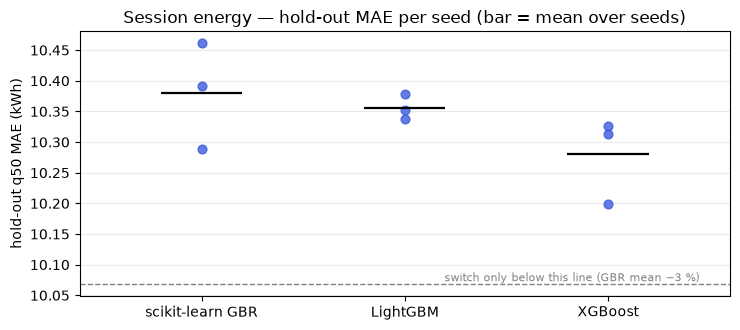

In [5]:
SEEDS = (42, 43, 44)
INCUMBENT = "sklearn_gbr"
MIN_GAIN_PCT, MAX_COVERAGE_DROP_PTS = 3.0, 5.0
LABELS = {"sklearn_gbr": "scikit-learn GBR", "lightgbm": "LightGBM", "xgboost": "XGBoost"}

# (estimator class, name of its quantile-level argument, capacity-matched parameters)
ESTIMATORS = {
    "sklearn_gbr": (GradientBoostingRegressor, "alpha", {
        "loss": "quantile", "init": "zero", "n_estimators": 200, "max_depth": 3,
        "learning_rate": 0.05, "min_samples_leaf": 25, "subsample": 0.85}),
    "lightgbm": (LGBMRegressor, "alpha", {
        "objective": "quantile", "n_estimators": 200, "max_depth": 3, "num_leaves": 8,
        "learning_rate": 0.05, "min_child_samples": 25, "subsample": 0.85, "subsample_freq": 1, "verbose": -1}),
    "xgboost": (XGBRegressor, "quantile_alpha", {
        "objective": "reg:quantileerror", "tree_method": "hist", "n_estimators": 200, "max_depth": 3,
        "learning_rate": 0.05, "min_child_weight": 25, "subsample": 0.85}),
}


def predict_sorted(models: dict, X: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    return tuple(np.sort(np.vstack([models[q].predict(X) for q in QUANTILES]), axis=0))


results, fitted_42 = {}, {}
for name, (cls, alpha_arg, params) in ESTIMATORS.items():
    runs = []
    for seed in SEEDS:
        models, fit_s = {}, 0.0
        for q, alpha in QUANTILES.items():
            est = cls(**params, **{alpha_arg: alpha}, random_state=seed)
            t0 = time.perf_counter()
            est.fit(X_tr, y_tr)
            fit_s += time.perf_counter() - t0
            models[q] = est
        runs.append({"seed": seed, "fit_s": round(fit_s, 2), **scores(y_te, *predict_sorted(models, X_te))})
        if seed == 42:
            fitted_42[name] = models
    mae = [r["mae_kwh"] for r in runs]
    results[name] = {"mae_kwh": round(float(np.mean(mae)), 3), "mae_min_kwh": min(mae), "mae_max_kwh": max(mae),
                     "coverage_pct": round(float(np.mean([r["coverage_q10_q90_pct"] for r in runs])), 1),
                     "fit_s": round(float(np.mean([r["fit_s"] for r in runs])), 2), "runs": runs}

verdicts = {}
inc = results[INCUMBENT]
for name, res in results.items():
    if name == INCUMBENT:
        continue
    gain = 100 * (inc["mae_kwh"] - res["mae_kwh"]) / inc["mae_kwh"]
    noise = 100 * max(inc["mae_max_kwh"] - inc["mae_min_kwh"], res["mae_max_kwh"] - res["mae_min_kwh"]) / inc["mae_kwh"]
    drop = inc["coverage_pct"] - res["coverage_pct"]
    failures = []
    if gain < MIN_GAIN_PCT:
        failures.append(f"MAE gain {gain:+.1f} % is below the {MIN_GAIN_PCT:g} % bar")
    if gain <= noise:
        failures.append(f"gap is within the {noise:.1f} % seed-to-seed range")
    if drop > MAX_COVERAGE_DROP_PTS:
        failures.append(f"coverage drops {drop:.1f} pts (limit {MAX_COVERAGE_DROP_PTS:g})")
    verdicts[name] = {"mae_gain_pct": round(gain, 1), "seed_range_pct": round(noise, 1),
                      "coverage_drop_pts": round(drop, 1), "passes": not failures,
                      "reason": "; ".join(failures) if failures else
                      f"MAE {gain:.1f} % lower (> {MIN_GAIN_PCT:g} % and > {noise:.1f} % seed range), coverage {-drop:+.1f} pts"}
passing = [n for n, v in verdicts.items() if v["passes"]]
SELECTED = max(passing, key=lambda n: verdicts[n]["mae_gain_pct"]) if passing else INCUMBENT


def selection_markdown() -> str:
    lines = ["| Algorithm | Hold-out q50 MAE (kWh), mean [min–max] | q10–q90 coverage | Fit time (3 quantiles) | Verdict |",
             "|---|---|---|---|---|"]
    for name, res in results.items():
        if name == INCUMBENT:
            verdict = "incumbent — **selected**" if SELECTED == INCUMBENT else "incumbent — replaced"
        else:
            verdict = ("**selected** — " if SELECTED == name else "rejected — ") + verdicts[name]["reason"]
        lines.append(f"| {LABELS[name]} | {res['mae_kwh']:.2f} [{res['mae_min_kwh']:.2f}–{res['mae_max_kwh']:.2f}] "
                     f"| {res['coverage_pct']:.1f} % | {res['fit_s']:.1f} s | {verdict} |")
    decision = (f"**{LABELS[INCUMBENT]} is retained** — no challenger cleared the rule."
                if SELECTED == INCUMBENT else f"**{LABELS[SELECTED]} replaces {LABELS[INCUMBENT]}** — it cleared every condition.")
    return "\n".join(lines) + f"\n\nMAE over seeds {', '.join(map(str, SEEDS))}.\n\n{decision}"


display(Markdown(selection_markdown()))

bar = inc["mae_kwh"] * (1 - MIN_GAIN_PCT / 100)
fig, ax = plt.subplots(figsize=(7.5, 3.4))
for i, (name, res) in enumerate(results.items()):
    maes = [r["mae_kwh"] for r in res["runs"]]
    ax.scatter([i] * len(maes), maes, s=40, color="#3b5bdb", alpha=0.8, zorder=3)
    ax.hlines(res["mae_kwh"], i - 0.2, i + 0.2, color="black", lw=1.6, zorder=4)
ax.axhline(bar, ls="--", lw=1, color="grey")
ax.text(len(results) - 0.55, bar, f"switch only below this line (GBR mean −{MIN_GAIN_PCT:g} %)",
        va="bottom", ha="right", fontsize=8, color="grey")
ax.set_xticks(range(len(results)), [LABELS[n] for n in results])
ax.set_xlim(-0.6, len(results) - 0.4)
ax.set_ylabel("hold-out q50 MAE (kWh)")
ax.set_title("Session energy — hold-out MAE per seed (bar = mean over seeds)")
ax.grid(alpha=0.25, axis="y")
fig.tight_layout()
plt.show()

## 6 · Final model and hold-out evaluation

The served model is the selected algorithm's seed-42 fit from the bake-off. It is compared with the
baseline and the two no-model references of §4 on the same held-out sessions, overall and per household.
The honest yardstick is the best of them, not the distance rule alone.

,scikit-learn GBR (served),baseline,constant (training median)
MAE (kWh),10.461,18.723,14.846
RMSE (kWh),14.197,25.883,18.446
bias (kWh),-1.904,-2.590,-7.003
q10–q90 coverage (%),79.600,36.100,87.800


MAE 44 % lower than the distance baseline, 30 % lower than the best no-model reference (14.85 kWh)


,sessions,model MAE (kWh),baseline MAE (kWh),constant MAE (kWh)
id01,21.0,10.31,13.60,15.23
id02,44.0,10.96,20.73,18.84
id03,31.0,8.37,15.07,13.67
id04,51.0,11.37,21.32,11.96


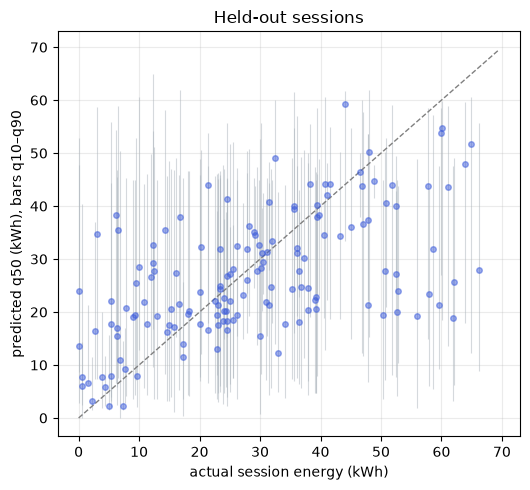

In [6]:
final = fitted_42[SELECTED]
lo, mid, hi = predict_sorted(final, X_te)
final_scores = scores(y_te, lo, mid, hi)
display(pd.DataFrame({f"{LABELS[SELECTED]} (served)": final_scores, "baseline": baseline_scores,
                      "constant (training median)": constant_scores}).rename(index={
    "mae_kwh": "MAE (kWh)", "rmse_kwh": "RMSE (kWh)", "bias_kwh": "bias (kWh)", "coverage_q10_q90_pct": "q10–q90 coverage (%)"}))
best_naive = min(constant_scores["mae_kwh"], trailing_scores["mae_kwh"])
print(f"MAE {100 * (1 - final_scores['mae_kwh'] / baseline_scores['mae_kwh']):.0f} % lower than the distance baseline, "
      f"{100 * (1 - final_scores['mae_kwh'] / best_naive):.0f} % lower than the best no-model reference ({best_naive:.2f} kWh)")

b_lo, b_mid, b_hi = baseline(test)
per_household = {}
for hid in HOUSEHOLDS:
    m = (test.household == hid).to_numpy()
    if m.any():
        per_household[hid] = {"sessions": int(m.sum()),
                              "model MAE (kWh)": round(float(np.mean(np.abs(mid[m] - y_te[m]))), 2),
                              "baseline MAE (kWh)": round(float(np.mean(np.abs(b_mid[m] - y_te[m]))), 2),
                              "constant MAE (kWh)": round(float(np.mean(np.abs(np.median(y_tr) - y_te[m]))), 2)}
per_household = pd.DataFrame(per_household).T
display(per_household)

fig, ax = plt.subplots(figsize=(5.4, 5.0))
ax.errorbar(y_te, mid, yerr=[mid - lo, hi - mid], fmt="o", ms=4, alpha=0.5, color="#3b5bdb", ecolor="#adb5bd", lw=0.8)
lim = max(y_te.max(), hi.max()) * 1.05
ax.plot([0, lim], [0, lim], ls="--", lw=1, color="grey")
ax.set_xlabel("actual session energy (kWh)")
ax.set_ylabel("predicted q50 (kWh), bars q10–q90")
ax.set_title("Held-out sessions")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 7 · Export — `Data/models/`

`Data/models/` is exactly the content of the Hugging Face repository
[`EnerTEF/EV-Service4-User-Charging-and-Usage-Profiles-Prediction`](https://huggingface.co/EnerTEF/EV-Service4-User-Charging-and-Usage-Profiles-Prediction):

| File | Content |
|---|---|
| `session_energy.joblib` | the fitted q10 / q50 / q90 estimators with the feature order |
| `metrics.json` | hold-out metrics vs the baseline, split, parameters, library versions |
| `benchmark.json` | the full bake-off: per-seed results, the rule and the verdicts |
| `requirements.txt` | the pinned environment in which the model loads |
| `example.py` | a short script that loads the sample data and runs the model (written here) |
| `example_sessions.csv` | the small open sample data set (written by `EV_External_Validation.ipynb` §3.7, not here) |
| `LICENSE` | the MIT licence (copied from the repository root) |
| `README.md` | the Hugging Face model card |

In [7]:
import shutil

EXAMPLE_PY = r'''"""Run the Service 4 session-energy model on the bundled open sample.

    pip install -r requirements.txt
    python example.py

Loads session_energy.joblib and example_sessions.csv (open Renault Zoe data-logger sessions, CC-BY-4.0, no timestamps), predicts the
q10 / q50 / q90 energy of every session and compares the median with the project's distance baseline. The sample is out of domain
for the model (different car, different charging context): it shows how to load and run the model, not how accurate it is.
"""
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import sklearn

REQUIRED_SKLEARN = "__REQUIRED_SKLEARN__"       # the pickle only loads on the scikit-learn release that wrote it
if sklearn.__version__ != REQUIRED_SKLEARN:
    sys.exit(f"session_energy.joblib needs scikit-learn {REQUIRED_SKLEARN}, found {sklearn.__version__}: pip install -r requirements.txt")

here = Path(__file__).resolve().parent
bundle = joblib.load(here / "session_energy.joblib")
data = pd.read_csv(here / "example_sessions.csv")

X = data[bundle["features"]].to_numpy(dtype=float)               # the feature order matters
data["q10"], data["q50"], data["q90"] = np.sort([bundle["quantiles"][q].predict(X) for q in ("q10", "q50", "q90")], axis=0)

# the project's no-model baseline: distance x 0.18 kWh/km (+5 % per trip beyond the first), clamped to 1-80 kWh
baseline = np.clip(data.recent_trip_km * 0.18 * (1 + 0.05 * np.maximum(0, data.trips_today - 1)), 1, 80)

print(data[["session", "recent_trip_km", "hour_of_day", "energy_kwh", "q10", "q50", "q90"]].head(8).round(1).to_string(index=False))
print()
for name, mask in (("all sessions", np.ones(len(data), bool)), ("context verified", data.context_verified.to_numpy())):
    d, b = data[mask], baseline[mask]
    print(f"{name:17s} n={len(d):3d} | model MAE {np.mean(np.abs(d.q50 - d.energy_kwh)):.2f} kWh | distance baseline MAE "
          f"{np.mean(np.abs(b - d.energy_kwh)):.2f} | q10-q90 coverage {100 * np.mean((d.q10 <= d.energy_kwh) & (d.energy_kwh <= d.q90)):.0f} %")
'''

assert LIBS["scikit-learn"] == REFERENCE_SKLEARN, \
    f"refusing to export: scikit-learn {LIBS['scikit-learn']} would write a model that the published environment ({REFERENCE_SKLEARN}) cannot load"
trained_at = datetime.now(timezone.utc).isoformat(timespec="seconds")
_, _, selected_params = ESTIMATORS[SELECTED]
joblib.dump({"model": "session_energy", "version": MODEL_VERSION, "algorithm": SELECTED, "features": FEATURES,
             "tariff_ordinal": TARIFF_ORDINAL, "quantiles": final, "trained_at": trained_at},
            MODEL_DIR / "session_energy.joblib")
split_info = {"method": "chronological 80/20 over all households", "n_train": len(train), "n_test": len(test),
              "train_window": [train.start.min().isoformat(), train.start.max().isoformat()],
              "test_window": [test.start.min().isoformat(), test.start.max().isoformat()]}
metrics = {"model_version": MODEL_VERSION, "trained_at": trained_at, "algorithm": SELECTED,
           "params": {**selected_params, "random_state": 42}, "quantiles": QUANTILES, "features": FEATURES,
           "split": split_info, "holdout": final_scores, "baseline_holdout": baseline_scores,
           "holdout_mean_actual_kwh": round(float(y_te.mean()), 2),
           "baseline_rule": "distance_km x 0.18 kWh/km x (1 + 0.05 x trips beyond the first today), clamped to 1-80 kWh",
           "naive_holdout": {"constant_training_median": constant_scores, "household_trailing_median_5": trailing_scores},
           "holdout_by_household": per_household.to_dict(orient="index"),
           "environment": {"python": platform.python_version(), **LIBS}}
(MODEL_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2, default=str), encoding="utf-8")
benchmark = {"created_at": trained_at, "seeds": list(SEEDS), "incumbent": INCUMBENT, "selected": SELECTED,
             "rule": {"min_gain_pct": MIN_GAIN_PCT, "max_coverage_drop_pts": MAX_COVERAGE_DROP_PTS,
                      "gain_must_exceed_seed_range": True},
             "params": {name: params for name, (_, _, params) in ESTIMATORS.items()},
             "results": results, "verdicts": verdicts, "split": split_info,
             "environment": {"python": platform.python_version(), **LIBS}}
(MODEL_DIR / "benchmark.json").write_text(json.dumps(benchmark, indent=2, default=str), encoding="utf-8")
(MODEL_DIR / "requirements.txt").write_text(
    "# Environment in which session_energy.joblib loads. It is a pickle: other scikit-learn releases fail to load it.\n"
    "# Python 3.11 (reference); 3.9-3.12 have wheels for these pins, 3.13 does not.\n"
    f"scikit-learn=={LIBS['scikit-learn']}\nnumpy=={LIBS['numpy']}\npandas=={LIBS['pandas']}\njoblib=={LIBS['joblib']}\n", encoding="utf-8")
(MODEL_DIR / "example.py").write_text(EXAMPLE_PY.replace("__REQUIRED_SKLEARN__", REFERENCE_SKLEARN), encoding="utf-8")
shutil.copyfile(ROOT / "LICENSE", MODEL_DIR / "LICENSE")
if not (MODEL_DIR / "example_sessions.csv").exists():
    print("NOTE: Data/models/example_sessions.csv is missing: run EV_External_Validation.ipynb "
          "(it writes the sample into the package; example.py and the model card need it).")
print("wrote:", ", ".join(sorted(p.name for p in MODEL_DIR.iterdir() if p.is_file())))

wrote: LICENSE, README.md, benchmark.json, example.py, example_sessions.csv, metrics.json, requirements.txt, session_energy.joblib


In [8]:
LIBRARY_TAG = {"sklearn_gbr": "scikit-learn", "lightgbm": "lightgbm", "xgboost": "xgboost"}[SELECTED]
CITATION = ("Avgoloupis, D. et al. Residential Energy Dataset with Electric Vehicles, Photovoltaic Generation and "
            "Tariff Variability in Ireland. Scientific Data 13:834 (2026). https://doi.org/10.1038/s41597-026-07186-3")
FEATURE_ROWS = "\n".join(f"| `{f}` | {d} |" for f, d in [
    ("recent_trip_km", "Distance driven since the previous session ended (km)."),
    ("trips_today", "Journeys started earlier on the session day."),
    ("hours_since_last_charge", "Hours since the previous session ended."),
    ("tariff_ordinal", "Tariff band at the session start: off-peak 0, shoulder 1, standard 2 (unknown), peak 3."),
    ("pv_today_kwh", "PV generated since midnight (kWh)."),
    ("hour_of_day", "Fractional hour of the session start (UTC)."),
    ("is_weekend", "1 on Saturday / Sunday, else 0."),
])

ZOE_CITATION = ("Morea, F., Alessandrini, S., Spadaro, M. Electric car parameters over 29 months. Area Science Park (2022). "
                "Zenodo. https://doi.org/10.5281/zenodo.7033914 (CC-BY-4.0)")

card = f'''---
license: mit
language:
- en
library_name: {LIBRARY_TAG}
pipeline_tag: tabular-regression
tags:
- energy
- ev-charging
- smart-charging
- quantile-regression
- gradient-boosting
- enertef
---

# Service 4 — residential EV session energy (quantile gradient boosting)

## Model description

Predicts the **energy a home charging session will deliver** (kWh) at the q10 / q50 / q90 quantiles,
from context available just before the session: recent driving, time since the last charge, the tariff
band and the PV generated that day. Built for the EnerTEF TEF-EV EV-user charging and usage profiles
prediction service (D2.2 §2.5.4); downstream smart charging gets a point estimate and an uncertainty band.

| Field | Value |
|---|---|
| Algorithm | {LABELS[SELECTED]} — 3 quantile regressors (q10 / q50 / q90), chosen by the bake-off below |
| Parameters | `{json.dumps({**selected_params, "random_state": 42})}` |
| Training sessions | {len(train)} (chronologically earliest 80 %, four households) |
| Held-out sessions | {len(test)} (most recent 20 %) |
| Version | {MODEL_VERSION} ({trained_at[:10]}) |

### Features (order matters)

| Feature | Meaning |
|---|---|
{FEATURE_ROWS}

## Repository contents

| File | Content |
|---|---|
| `session_energy.joblib` | dict with `features` (order), `tariff_ordinal`, `quantiles` (`q10`/`q50`/`q90` estimators) and metadata |
| `example.py` | short script: loads the sample data and runs the model (see *Installation and inference*) |
| `example_sessions.csv` | small open sample data set (see *Inputs and data*) |
| `requirements.txt` | the pinned environment in which the model loads |
| `metrics.json` | hold-out metrics vs the baseline, split, parameters, library versions |
| `benchmark.json` | algorithm bake-off: per-seed results, rule, verdicts |
| `LICENSE` | MIT licence of the model and code (the sample data keeps its own licence, below) |

## Inputs and data

### Training data (restricted, not included)

**Residential energy dataset with electric vehicles, PV generation and tariff variability in Ireland** —
annotated EV home-charging sessions, journeys, household energy streams, PV generation and tariff data
for four "ambassador" households (`id01`–`id04`) of the ESB Networks Dingle Electrification Project.

{CITATION}

**The dataset is not redistributed here.** It describes four real households, so it stays with its owners;
household identifiers are pseudonymous — do not attempt re-identification. Obtain it via the data paper.

### Sample data (open): `example_sessions.csv`

62 charging sessions of two cars from an open data-logger data set: Morea, Alessandrini & Spadaro,
*Electric car parameters over 29 months* (Area Science Park, 2022,
[doi:10.5281/zenodo.7033914](https://doi.org/10.5281/zenodo.7033914), **CC-BY-4.0** — the sample keeps that licence and
attribution). It was converted to this model's input schema by the notebook `EV_External_Validation.ipynb` (§3.7) of the project
repository; timestamps are removed.

| Column | Meaning |
|---|---|
| `session`, `vehicle` | session id; car `A` (about 22 kWh pack) or car `B` (about 37 kWh pack) |
| the 7 features | exactly as above, in model order; `tariff_ordinal` is 2 (unknown) and `pv_today_kwh` is 0 in every row because the logger records neither |
| `energy_kwh` | measured energy of the session, **battery side** (state-of-charge gain × pack size; the training target is measured at the wallbox) |
| `context_verified` | `True` for the 41 sessions whose pre-session context was checked complete (odometer and state-of-charge continuity) |

The sample is **out of domain** (other cars, mostly short morning top-ups, a different charging context): it shows how to load
and run the model, not how accurate it is (see *How good is it?*).

## Installation and inference

### Requirements

`session_energy.joblib` is a pickle: it **only loads on the scikit-learn release that wrote it ({LIBS["scikit-learn"]})** and fails on 1.6 / 1.7 with
`AttributeError: Can't get attribute '__pyx_unpickle_CyPinballLoss'`. Use Python 3.11 (3.9–3.12 have wheels) and the pins in `requirements.txt`:

```
scikit-learn=={LIBS["scikit-learn"]}
numpy=={LIBS["numpy"]}
pandas=={LIBS["pandas"]}
joblib=={LIBS["joblib"]}
```

### Run the bundled example

```bash
pip install -r requirements.txt
python example.py
```

It prints the q10 / q50 / q90 prediction of the first sessions and the error against the project's distance baseline. The last lines
are:

```
all sessions      n= 62 | model MAE 5.19 kWh | distance baseline MAE 4.42 | q10-q90 coverage 87 %
context verified  n= 41 | model MAE 3.67 kWh | distance baseline MAE 3.98 | q10-q90 coverage 93 %
```

### Predict one session

```python
import joblib
import numpy as np
import sklearn

assert sklearn.__version__ == "{LIBS["scikit-learn"]}", "session_energy.joblib needs scikit-learn {LIBS["scikit-learn"]} (see Requirements)"
bundle = joblib.load("session_energy.joblib")
# Feature order: recent_trip_km, trips_today, hours_since_last_charge, tariff_ordinal,
#                pv_today_kwh, hour_of_day, is_weekend
x = [[12.5, 2.0, 8.0, 0.0, 0.0, 18.5, 0.0]]
lo, mid, hi = np.sort([est.predict(x)[0] for est in bundle["quantiles"].values()])
# the model has no battery-capacity input: clip to the pack size of the vehicle (kWh)
lo, mid, hi = (min(v, 64.0) for v in (lo, mid, hi))   # 64 kWh = the pilot's Hyundai Kona
```

## Evaluation

### Hold-out accuracy (pilot households)

| Metric | {LABELS[SELECTED]} | Distance baseline¹ | Constant (training median) |
|---|---|---|---|
| MAE (kWh) | {final_scores["mae_kwh"]:.2f} | {baseline_scores["mae_kwh"]:.2f} | {constant_scores["mae_kwh"]:.2f} |
| RMSE (kWh) | {final_scores["rmse_kwh"]:.2f} | {baseline_scores["rmse_kwh"]:.2f} | {constant_scores["rmse_kwh"]:.2f} |
| q10–q90 coverage | {final_scores["coverage_q10_q90_pct"]:.1f} % | {baseline_scores["coverage_q10_q90_pct"]:.1f} % | {constant_scores["coverage_q10_q90_pct"]:.1f} % |

MAE is {100 * (1 - final_scores["mae_kwh"] / baseline_scores["mae_kwh"]):.0f} % lower than the distance baseline, but the distance rule is a weak yardstick (a constant beats it):
against the best no-model reference ({best_naive:.2f} kWh, a constant training median) it is **{100 * (1 - final_scores["mae_kwh"] / best_naive):.0f} % lower**.
The constant's q10–q90 band is the training quantiles, which over-cover.

¹ The project's no-model rule: distance since the previous session × 0.18 kWh/km, plus 5 % per trip beyond the first that day, clamped to 1–80 kWh.

### How good is it?

A demonstrator that learns something real about session size inside its own four households — not a validated general predictor.

- **In-domain, real but modest in absolute terms:** MAE {final_scores["mae_kwh"]:.1f} kWh on held-out sessions averaging {y_te.mean():.1f} kWh; the q10–q90 band holds close to its nominal 80 % ({final_scores["coverage_q10_q90_pct"]:.1f} %).
- **No demonstrated transfer.** On a different vehicle (the 62 sessions of the open sample above) its MAE was 5.2 kWh against 4.4 kWh for the distance baseline on all sessions, and 3.7 against 4.0 on the 41 sessions with a verified-complete context; both differences are within noise (95 % intervals include zero). A small, heterogeneous sample, so a smoke test, not a benchmark (notebook `EV_External_Validation.ipynb`).
- **No battery-capacity input:** it can predict more energy than a pack holds. Clip to the pack size of the vehicle you predict for.
- **Weak after long gaps:** sessions more than ~400 h after the previous one are poorly covered by the training data (its 90th percentile is ~100 h) and were badly under-predicted out of domain.
- **Data, not algorithm, is the limit:** LightGBM and XGBoost are within seed noise of the selected model (below).

### Model selection — why {LABELS[SELECTED]}

scikit-learn GBR (the incumbent), LightGBM and XGBoost were trained on the same sessions and split, with
the same capacity translated to each library and no per-library tuning, over three seeds. The rule was
fixed before the run: a challenger replaces GBR only if its q50 MAE is at least {MIN_GAIN_PCT:g} % lower,
the gap exceeds the seed-to-seed range, and its q10–q90 coverage drops by at most {MAX_COVERAGE_DROP_PTS:g} points.

{selection_markdown()}

Per-seed results: `benchmark.json`.

## Reproduce the workflow

The model, its bake-off and this card are produced by `EV_Session_Energy_Model.ipynb` in the project repository
([{GITHUB_REPO.split("/")[-1]}]({GITHUB_REPO})); `EV_Charging_Analysis.ipynb` holds the analysis behind the service and
`EV_External_Validation.ipynb` the external validation. The first two need the restricted training data; the validation notebook
downloads open data. Use Python 3.11 and the repository's pinned `requirements.txt`.

## Intended uses and limitations

**Intended use:** research and demonstration of smart-charging inputs for residential home charging — an energy estimate with an
uncertainty band for a session that is about to start. **Not intended for:** billing, safety-critical or grid-operational control,
vehicles or charging contexts unlike the pilot's, or predicting whether or when a session starts.

- Four households only ({len(train)} training sessions): a demonstrator, not a general-purpose predictor.
- No demonstrated transfer to other vehicles or usage, and no battery-capacity input (see *How good is it?*).
- Poorly covered: very long gaps since the last charge.
- The q10–q90 band is empirical; its coverage is reported above against a nominal 80 %.
- Whether and when a session starts is a separate question, not answered by this model.
- Needs scikit-learn {LIBS["scikit-learn"]} exactly (see *Requirements*).

## License and project references

Model and code: MIT (`LICENSE`). Sample data: CC-BY-4.0 (Morea et al., above). Part of the EnerTEF project
([huggingface.co/EnerTEF](https://huggingface.co/EnerTEF)), TEF-EV node, Service 4 (EV-user charging and usage profiles
prediction, D2.2 §2.5.4). Code and the full experiment: [{GITHUB_REPO.split("/")[-1]}]({GITHUB_REPO}).

## Citation

Training data: {CITATION}

Sample data: {ZOE_CITATION}
'''
(MODEL_DIR / "README.md").write_text(card, encoding="utf-8")
display(Markdown(card.split("### Model selection")[0].split("---", 2)[2]))



# Service 4 — residential EV session energy (quantile gradient boosting)

## Model description

Predicts the **energy a home charging session will deliver** (kWh) at the q10 / q50 / q90 quantiles,
from context available just before the session: recent driving, time since the last charge, the tariff
band and the PV generated that day. Built for the EnerTEF TEF-EV EV-user charging and usage profiles
prediction service (D2.2 §2.5.4); downstream smart charging gets a point estimate and an uncertainty band.

| Field | Value |
|---|---|
| Algorithm | scikit-learn GBR — 3 quantile regressors (q10 / q50 / q90), chosen by the bake-off below |
| Parameters | `{"loss": "quantile", "init": "zero", "n_estimators": 200, "max_depth": 3, "learning_rate": 0.05, "min_samples_leaf": 25, "subsample": 0.85, "random_state": 42}` |
| Training sessions | 587 (chronologically earliest 80 %, four households) |
| Held-out sessions | 147 (most recent 20 %) |
| Version | 1.0.0 (2026-10-02) |

### Features (order matters)

| Feature | Meaning |
|---|---|
| `recent_trip_km` | Distance driven since the previous session ended (km). |
| `trips_today` | Journeys started earlier on the session day. |
| `hours_since_last_charge` | Hours since the previous session ended. |
| `tariff_ordinal` | Tariff band at the session start: off-peak 0, shoulder 1, standard 2 (unknown), peak 3. |
| `pv_today_kwh` | PV generated since midnight (kWh). |
| `hour_of_day` | Fractional hour of the session start (UTC). |
| `is_weekend` | 1 on Saturday / Sunday, else 0. |

## Repository contents

| File | Content |
|---|---|
| `session_energy.joblib` | dict with `features` (order), `tariff_ordinal`, `quantiles` (`q10`/`q50`/`q90` estimators) and metadata |
| `example.py` | short script: loads the sample data and runs the model (see *Installation and inference*) |
| `example_sessions.csv` | small open sample data set (see *Inputs and data*) |
| `requirements.txt` | the pinned environment in which the model loads |
| `metrics.json` | hold-out metrics vs the baseline, split, parameters, library versions |
| `benchmark.json` | algorithm bake-off: per-seed results, rule, verdicts |
| `LICENSE` | MIT licence of the model and code (the sample data keeps its own licence, below) |

## Inputs and data

### Training data (restricted, not included)

**Residential energy dataset with electric vehicles, PV generation and tariff variability in Ireland** —
annotated EV home-charging sessions, journeys, household energy streams, PV generation and tariff data
for four "ambassador" households (`id01`–`id04`) of the ESB Networks Dingle Electrification Project.

Avgoloupis, D. et al. Residential Energy Dataset with Electric Vehicles, Photovoltaic Generation and Tariff Variability in Ireland. Scientific Data 13:834 (2026). https://doi.org/10.1038/s41597-026-07186-3

**The dataset is not redistributed here.** It describes four real households, so it stays with its owners;
household identifiers are pseudonymous — do not attempt re-identification. Obtain it via the data paper.

### Sample data (open): `example_sessions.csv`

62 charging sessions of two cars from an open data-logger data set: Morea, Alessandrini & Spadaro,
*Electric car parameters over 29 months* (Area Science Park, 2022,
[doi:10.5281/zenodo.7033914](https://doi.org/10.5281/zenodo.7033914), **CC-BY-4.0** — the sample keeps that licence and
attribution). It was converted to this model's input schema by the notebook `EV_External_Validation.ipynb` (§3.7) of the project
repository; timestamps are removed.

| Column | Meaning |
|---|---|
| `session`, `vehicle` | session id; car `A` (about 22 kWh pack) or car `B` (about 37 kWh pack) |
| the 7 features | exactly as above, in model order; `tariff_ordinal` is 2 (unknown) and `pv_today_kwh` is 0 in every row because the logger records neither |
| `energy_kwh` | measured energy of the session, **battery side** (state-of-charge gain × pack size; the training target is measured at the wallbox) |
| `context_verified` | `True` for the 41 sessions whose pre-session context was checked complete (odometer and state-of-charge continuity) |

The sample is **out of domain** (other cars, mostly short morning top-ups, a different charging context): it shows how to load
and run the model, not how accurate it is (see *How good is it?*).

## Installation and inference

### Requirements

`session_energy.joblib` is a pickle: it **only loads on the scikit-learn release that wrote it (1.5.2)** and fails on 1.6 / 1.7 with
`AttributeError: Can't get attribute '__pyx_unpickle_CyPinballLoss'`. Use Python 3.11 (3.9–3.12 have wheels) and the pins in `requirements.txt`:

```
scikit-learn==1.5.2
numpy==1.26.4
pandas==2.2.3
joblib==1.4.2
```

### Run the bundled example

```bash
pip install -r requirements.txt
python example.py
```

It prints the q10 / q50 / q90 prediction of the first sessions and the error against the project's distance baseline. The last lines
are:

```
all sessions      n= 62 | model MAE 5.19 kWh | distance baseline MAE 4.42 | q10-q90 coverage 87 %
context verified  n= 41 | model MAE 3.67 kWh | distance baseline MAE 3.98 | q10-q90 coverage 93 %
```

### Predict one session

```python
import joblib
import numpy as np
import sklearn

assert sklearn.__version__ == "1.5.2", "session_energy.joblib needs scikit-learn 1.5.2 (see Requirements)"
bundle = joblib.load("session_energy.joblib")
# Feature order: recent_trip_km, trips_today, hours_since_last_charge, tariff_ordinal,
#                pv_today_kwh, hour_of_day, is_weekend
x = [[12.5, 2.0, 8.0, 0.0, 0.0, 18.5, 0.0]]
lo, mid, hi = np.sort([est.predict(x)[0] for est in bundle["quantiles"].values()])
# the model has no battery-capacity input: clip to the pack size of the vehicle (kWh)
lo, mid, hi = (min(v, 64.0) for v in (lo, mid, hi))   # 64 kWh = the pilot's Hyundai Kona
```

## Evaluation

### Hold-out accuracy (pilot households)

| Metric | scikit-learn GBR | Distance baseline¹ | Constant (training median) |
|---|---|---|---|
| MAE (kWh) | 10.46 | 18.72 | 14.85 |
| RMSE (kWh) | 14.20 | 25.88 | 18.45 |
| q10–q90 coverage | 79.6 % | 36.1 % | 87.8 % |

MAE is 44 % lower than the distance baseline, but the distance rule is a weak yardstick (a constant beats it):
against the best no-model reference (14.85 kWh, a constant training median) it is **30 % lower**.
The constant's q10–q90 band is the training quantiles, which over-cover.

¹ The project's no-model rule: distance since the previous session × 0.18 kWh/km, plus 5 % per trip beyond the first that day, clamped to 1–80 kWh.

### How good is it?

A demonstrator that learns something real about session size inside its own four households — not a validated general predictor.

- **In-domain, real but modest in absolute terms:** MAE 10.5 kWh on held-out sessions averaging 28.6 kWh; the q10–q90 band holds close to its nominal 80 % (79.6 %).
- **No demonstrated transfer.** On a different vehicle (the 62 sessions of the open sample above) its MAE was 5.2 kWh against 4.4 kWh for the distance baseline on all sessions, and 3.7 against 4.0 on the 41 sessions with a verified-complete context; both differences are within noise (95 % intervals include zero). A small, heterogeneous sample, so a smoke test, not a benchmark (notebook `EV_External_Validation.ipynb`).
- **No battery-capacity input:** it can predict more energy than a pack holds. Clip to the pack size of the vehicle you predict for.
- **Weak after long gaps:** sessions more than ~400 h after the previous one are poorly covered by the training data (its 90th percentile is ~100 h) and were badly under-predicted out of domain.
- **Data, not algorithm, is the limit:** LightGBM and XGBoost are within seed noise of the selected model (below).



## 8 · Publish to Hugging Face (opt-in)

Uploads `Data/models/` to `EnerTEF/EV-Service4-User-Charging-and-Usage-Profiles-Prediction` ([the EnerTEF organisation](https://huggingface.co/EnerTEF); change `HF_REPO` in §1 to rename it). Training data is never uploaded.

**What you need**

1. A logged-in token (`hf auth login`, or `HF_TOKEN`) that may write to the **EnerTEF organisation**. A *fine-grained* token is
   limited to the namespaces it lists, so a token that only covers your personal account gets `403 … You don't have the rights to
   create a model under the namespace "EnerTEF"`. Open <https://huggingface.co/settings/tokens>, edit the token, add **EnerTEF**
   under *Org permissions* and grant write access to repos (a classic **Write** token also works).
2. Membership of EnerTEF with a role that may create or write repos (*write* or *admin*).

**What the cell does.** It checks who you are and what the token may do, then uploads into the repo if it exists, otherwise creates
it **private** (make it public on huggingface.co after reviewing the card) and uploads. It lists the remote files that the upload
would remove (those matching `DELETE_PATTERNS` that are not in the package folder) and **stops** unless you set
`ALLOW_REMOTE_DELETIONS = True`. Missing permission stops it with an explanation instead of a bare 403.

**If you cannot create repos in the organisation:** ask an admin to create the empty repo and give you write access; the cell skips
creation when the repo exists. With read access only, set `OPEN_PULL_REQUEST = True`: the files are proposed as a pull request that
an admin merges. To rehearse without touching the organisation, set `HF_REPO_OVERRIDE` to a repo in your own namespace.


In [9]:
UPLOAD_TO_HF = False          # set True to publish
DELETE_PATTERNS = ["*.json", "*.joblib"]   # remote files matching these and absent from the package folder are removed by the upload
ALLOW_REMOTE_DELETIONS = False          # the upload stops if it would delete remote files, unless this is True
HF_REPO_OVERRIDE = None       # e.g. "your-name/<repo>" to rehearse in your own namespace
NEW_REPO_PRIVATE = True       # a repo created by this cell starts private; flip it public on huggingface.co after review
OPEN_PULL_REQUEST = False     # True: propose the files as a pull request instead of committing (needs only read access)


def publish_to_hf():
    from fnmatch import fnmatch

    from huggingface_hub import HfApi
    from huggingface_hub.errors import HfHubHTTPError

    repo = HF_REPO_OVERRIDE or HF_REPO
    namespace = repo.split("/")[0]
    api = HfApi()

    def status(err):
        return err.response.status_code if getattr(err, "response", None) is not None else None

    # ---- who am I, and may this token write to the target namespace? (read-only checks, nothing is changed yet) ----
    try:
        me = api.whoami()
    except Exception as err:
        raise RuntimeError("Not logged in to Hugging Face: run `hf auth login` (or set HF_TOKEN) with a token that may write "
                           f"to '{namespace}', then run this cell again.") from err
    token = (me.get("auth") or {}).get("accessToken") or {}
    token_type = token.get("role")
    scoped = {(s.get("entity") or {}).get("name") for s in (token.get("fineGrained") or {}).get("scoped", [])} - {None}
    org = next((o for o in me.get("orgs", []) if o.get("name") == namespace), None)
    print(f"logged in as {me.get('name')} · token type: {token_type} · target: {repo}")
    if namespace != me.get("name") and org is None:
        raise PermissionError(f"{me.get('name')} is not a member of '{namespace}': ask an admin to invite you "
                              f"(https://huggingface.co/organizations/{namespace}/settings/members).")
    if token_type == "read":
        raise PermissionError("This token is read-only. Create a Write token (or a fine-grained token with write access to "
                              f"'{namespace}') at https://huggingface.co/settings/tokens.")
    if token_type == "fineGrained" and namespace not in scoped:
        raise PermissionError(
            f"This fine-grained token has no permissions for '{namespace}' (it covers: {sorted(scoped) or 'nothing'}). Edit it at "
            f"https://huggingface.co/settings/tokens: add '{namespace}' under 'Org permissions' and grant write access to repos "
            "(or create a Write token), then run this cell again.")

    # ---- the repo: upload into it if it exists, create it only if it does not ----
    local = sorted(p.name for p in MODEL_DIR.iterdir() if p.is_file())
    exists = api.repo_exists(repo, repo_type="model")
    if exists:
        remote = api.list_repo_files(repo, repo_type="model")
        removed = [f for f in remote if any(fnmatch(f, pat) for pat in DELETE_PATTERNS) and f not in local]
        print(f"repo exists; uploading {local}; the upload will remove {removed or 'nothing'}")
        if removed and not ALLOW_REMOTE_DELETIONS:
            raise RuntimeError(f"The upload would delete {removed} from '{repo}'. If that is intended (for example a new version replaces "
                               "an old one), set ALLOW_REMOTE_DELETIONS = True and run this cell again; otherwise keep those files "
                               "in the package folder or narrow DELETE_PATTERNS.")
    elif OPEN_PULL_REQUEST:
        raise RuntimeError(f"OPEN_PULL_REQUEST needs an existing repo: ask an admin to create '{repo}' first.")
    else:
        try:
            api.create_repo(repo, repo_type="model", private=NEW_REPO_PRIVATE)
            print(f"created {repo} ({'private' if NEW_REPO_PRIVATE else 'public'}); uploading {local}")
        except HfHubHTTPError as err:
            if status(err) == 409:
                print("the repo already exists but is not visible to this token; trying the upload")
            elif status(err) == 403:
                raise PermissionError(
                    f"You may not create repos in '{namespace}' (your role: {(org or {}).get('roleInOrg') or 'not shown'}). Ask an admin "
                    f"to create the empty repo '{repo}' and give you write access, then run this cell again (creation is skipped when "
                    "the repo exists); or set OPEN_PULL_REQUEST = True once it exists, or HF_REPO_OVERRIDE to a repo in your own namespace.") from err
            else:
                raise

    # ---- upload ----
    try:
        commit = api.upload_folder(repo_id=repo, repo_type="model", folder_path=str(MODEL_DIR),
                                   commit_message=f"Service 4 session-energy model v{MODEL_VERSION}",
                                   delete_patterns=DELETE_PATTERNS, create_pr=OPEN_PULL_REQUEST)
    except HfHubHTTPError as err:
        if status(err) in (401, 403, 404):
            raise PermissionError(f"Not allowed to write to '{repo}' (HTTP {status(err)}): you need write access to the repo, or set "
                                  "OPEN_PULL_REQUEST = True to propose the files as a pull request.") from err
        raise
    if OPEN_PULL_REQUEST:
        print(f"pull request opened: {commit.pr_url}  (an admin merges it)")
    else:
        try:
            visibility = "private" if api.model_info(repo).private else "public"
        except Exception:
            visibility = "visibility unknown"
        print(f"published: https://huggingface.co/{repo}  ({visibility})")


if UPLOAD_TO_HF:
    publish_to_hf()
else:
    print(f"not uploaded - review {MODEL_DIR.relative_to(ROOT).as_posix()}/README.md, then set UPLOAD_TO_HF = True to publish to {HF_REPO_OVERRIDE or HF_REPO}")


not uploaded - review Data/models/README.md, then set UPLOAD_TO_HF = True to publish to EnerTEF/EV-Service4-User-Charging-and-Usage-Profiles-Prediction
